# Cyber Trend Forecasting - SARIMAX Gap-Fill Analysis

**Vignette Description:**
This notebook walks through the SARIMAX analysis used to fill the Feb-Dec 2025 gap in the
Hackmageddon incident data.

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [1]:
import os
import sys

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root

try:
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

if IS_COLAB:
    try:
        drive.mount('/content/drive')
        PROJECT_ROOT = userdata.get('project_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")
    except Exception as e:
        print(f"COLAB SETUP ERROR: {e}")
        raise e
else:
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# This vignette works from the Hackmageddon data directory
GAPFILL_DIR = os.path.join(PROJECT_ROOT, 'Data_Preparation', 'Hackmageddon_Attacks')
OUTPUTS_DIR = os.path.join(GAPFILL_DIR, 'gapfill_outputs')

if not os.path.exists(OUTPUTS_DIR):
    raise FileNotFoundError(f"Could not find gap-fill outputs at: {OUTPUTS_DIR}")

os.chdir(PROJECT_ROOT)
# print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

--- Detected Environment: LOCAL SERVER (NATO/BBK) ---


## Step 1: Holdout Validation - the Headline MAE

Training on Jan-2012 to Apr-2024, prediction on May-2024 to Jan-2025. We compare three methods on same splits:

| Method | Description |
|---|---|
| `sarimax-exog` | SARIMAX with the Reddit war/conflict signals as external input |
| `sarima` | the same model family with NO external input to isolate the Reddit contribution |
| `seasonal-naive` | predict this month = same month last year (standard baseline) |

We evaluate at two aggregation levels. First, the 26 attack-type totals (`-ALL` columns  with high-volume series where monthly counts are in hundreds to thousands) and all 988 series which contain mostly small country-lvel counts, hence the much smaller absolute MAE.

In [2]:
import pandas as pd

metrics = pd.read_csv(os.path.join(OUTPUTS_DIR, 'holdout_metrics.csv'))
agg = metrics[metrics.scope == 'aggregate']

print('--- Holdout MAE by horizon (months into the holdout window) ---')
mae_pivot = agg.pivot_table(index=['series', 'method'], columns='horizon',
                            values='mae').round(2)
display(mae_pivot)

print('--- Holdout RAE (MAE / MAE of predicting the mean) ---')
rae_pivot = agg.pivot_table(index=['series', 'method'], columns='horizon',
                            values='rae').round(3)
display(rae_pivot)

--- Holdout MAE by horizon (months into the holdout window) ---


horizon                         3      6      9  Overall
series      method                                      
ALL-totals  sarima          58.43  71.64  78.38    78.38
            sarimax-exog    58.82  60.36  64.50    64.50
            seasonal-naive  66.87  71.01  77.89    77.89
all-targets sarima           2.83   3.33   3.76     3.76
            sarimax-exog     2.93   3.09   3.38     3.38
            seasonal-naive   3.71   3.86   4.21     4.21

--- Holdout RAE (MAE / MAE of predicting the mean) ---


horizon                         3      6      9  Overall
series      method                                      
ALL-totals  sarima          0.293  0.366  0.419    0.419
            sarimax-exog    0.295  0.308  0.344    0.344
            seasonal-naive  0.335  0.362  0.416    0.416
all-targets sarima          0.220  0.263  0.312    0.312
            sarimax-exog    0.228  0.244  0.281    0.281
            seasonal-naive  0.288  0.305  0.350    0.350

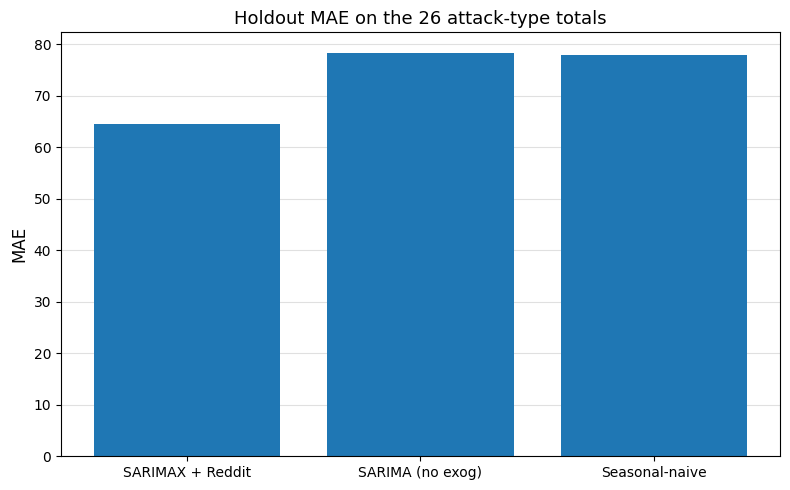

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Overall MAE comparison chart (attack-type totals)
sub = agg[(agg.series == 'ALL-totals') & (agg.horizon == 'Overall')]
order = ['sarimax-exog', 'sarima', 'seasonal-naive']
vals = [float(sub[sub.method == m].mae.iloc[0]) for m in order]
labels = ['SARIMAX + Reddit', 'SARIMA (no exog)', 'Seasonal-naive']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, vals)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Holdout MAE on the 26 attack-type totals', fontsize=13)
ax.set_axisbelow(True)
ax.grid(True, axis='y', linestyle='-', color='lightgray', alpha=0.7)
plt.tight_layout()
plt.show()

### Advantage increases with horizon

At the 3 month horizon plain SARIMA is marginally ahead. The Reddit advantage appears as the horizon longer horizons. At full 9 months SARIMAX is ~14 MAE ahead of both baselines and the totals.

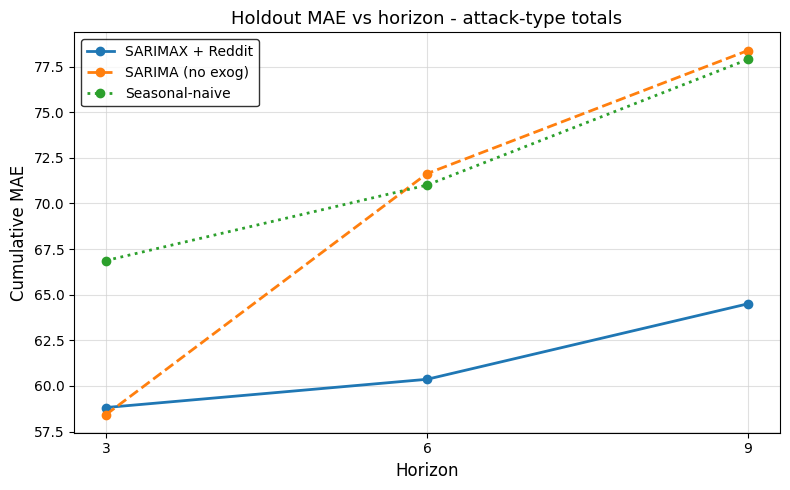

In [4]:
sub = agg[agg.series == 'ALL-totals']
fig, ax = plt.subplots(figsize=(8, 5))
for m, lbl,  ls in [('sarimax-exog', 'SARIMAX + Reddit',  '-'),
                      ('sarima', 'SARIMA (no exog)', '--'),
                      ('seasonal-naive', 'Seasonal-naive', ':')]:
    s = sub[(sub.method == m) & (sub.horizon != 'Overall')]
    hs = s.horizon.astype(int)
    ax.plot(hs, s.mae, ls, marker='o', linewidth=2, label=lbl)
ax.set_xlabel('Horizon', fontsize=12)
ax.set_ylabel('Cumulative MAE', fontsize=12)
ax.set_title('Holdout MAE vs horizon - attack-type totals', fontsize=13)
ax.set_xticks([3, 6, 9])
ax.legend(frameon=True, edgecolor='black')
ax.set_axisbelow(True)
ax.grid(True, linestyle='-', color='lightgray', alpha=0.7)
plt.tight_layout()
plt.show()

## Step 2: Predicted vs Actual

The holdout predictions for every series and method are found in  `holdout_predictions.csv`. The four largest attack-type totals, showing the 9 held-out months. The SARIMAX line tracks the 2024 surge.

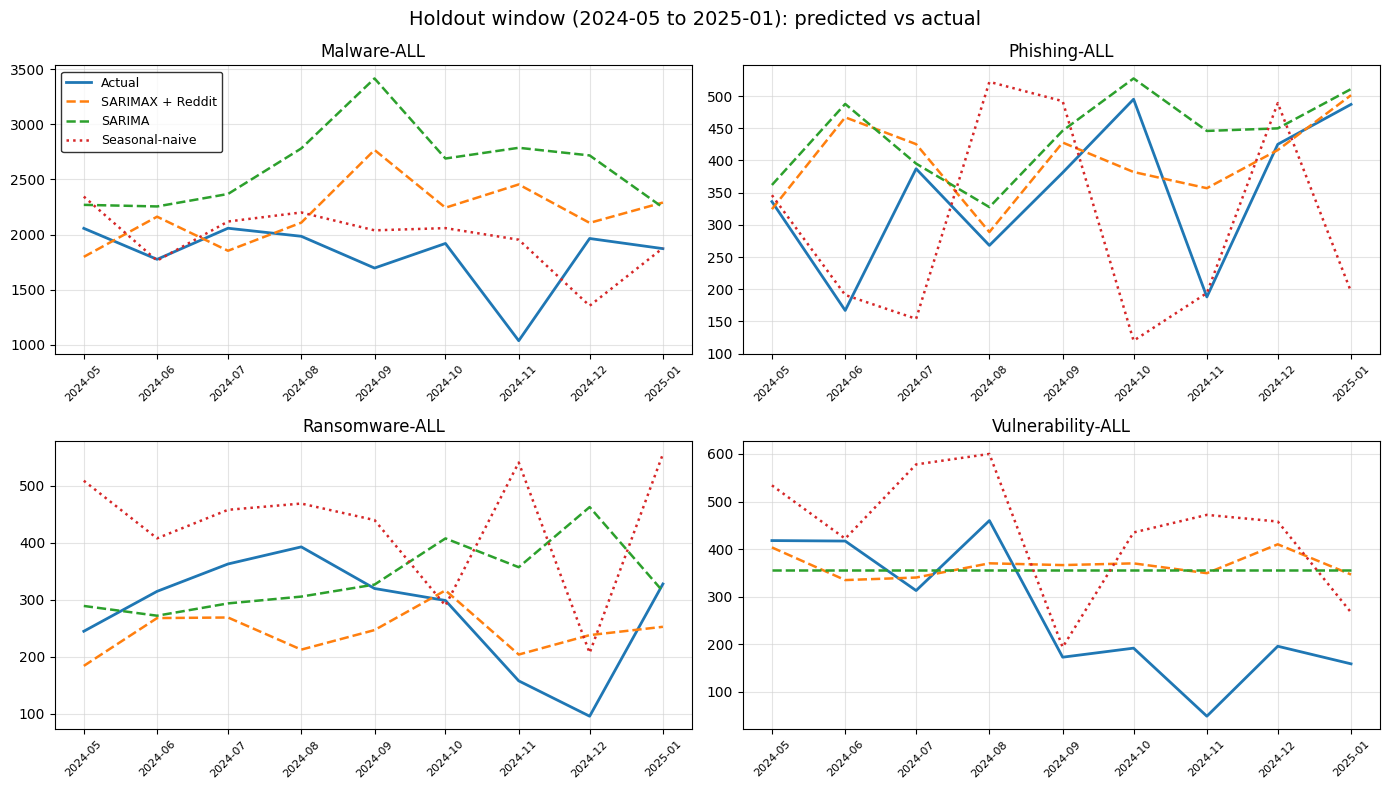

In [5]:
preds = pd.read_csv(os.path.join(OUTPUTS_DIR, 'holdout_predictions.csv'))
preds['period'] = pd.PeriodIndex(preds.period, freq='M')

SHOW = ['Malware-ALL', 'Phishing-ALL', 'Ransomware-ALL', 'Vulnerability-ALL']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, name in zip(axes.ravel(), SHOW):
    s = preds[preds.series == name]
    truth = s[s.method == 'sarimax-exog'].sort_values('period')
    ax.plot(truth.period.dt.to_timestamp(), truth.truth,
            linewidth=2, label='Actual')
    for m, lbl, ls in [('sarimax-exog', 'SARIMAX + Reddit', '--'),
                          ('sarima', 'SARIMA', '--'),
                          ('seasonal-naive', 'Seasonal-naive', ':')]:
        mm = s[s.method == m].sort_values('period')
        ax.plot(mm.period.dt.to_timestamp(), mm.prediction, ls,
                 linewidth=1.8, label=lbl)
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='-', color='lightgray', alpha=0.6)
axes[0, 0].legend(fontsize=9, frameon=True, edgecolor='black')
fig.suptitle('Holdout window (2024-05 to 2025-01): predicted vs actual', fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Gapfill

The gapfill re-fits every series on real data (through Jan-2025) and writes the Feb-Dec 2025 predictions into `NoI_monthly_v2_filled_sarimax.csv`.

The filled attack columns were then merged with the v2.1 non-attack columns to create
`Cyber_Trend_Forecasting_All_v2_2_sarimax.csv`.

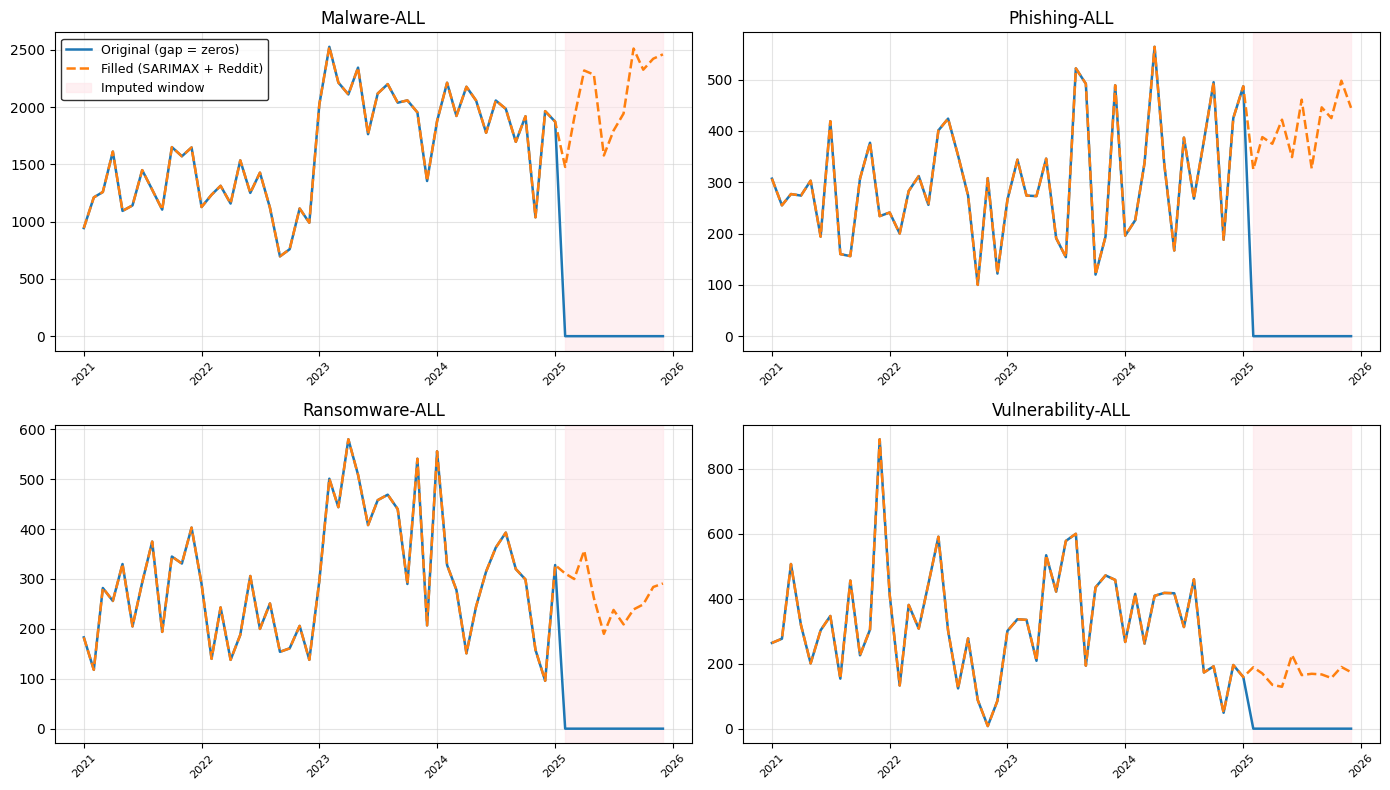

In [6]:
import json

raw = pd.read_csv(os.path.join(GAPFILL_DIR, 'NoI_monthly_v2.csv'))
filled = pd.read_csv(os.path.join(GAPFILL_DIR, 'NoI_monthly_v2_filled_sarimax.csv'))
dates = pd.to_datetime(raw.iloc[:, 0], format='%m/%Y')

SHOW = ['Malware-ALL', 'Phishing-ALL', 'Ransomware-ALL', 'Vulnerability-ALL']
last = 60  # months to display
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
gap_start = pd.Timestamp('2025-02-01')
for ax, name in zip(axes.ravel(), SHOW):
    ax.plot(dates[-last:], raw[name].values[-last:],
             linewidth=1.8, label='Original (gap = zeros)')
    ax.plot(dates[-last:], filled[name].values[-last:], '--',
             linewidth=1.8, label='Filled (SARIMAX + Reddit)')
    ax.axvspan(gap_start, dates.iloc[-1], color='#fee6ea', alpha=0.6,
               label='Imputed window')
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='-', color='lightgray', alpha=0.6)
axes[0, 0].legend(fontsize=9, frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()

## Optional: Re-Run the Analysis from Scratch

Both stages are one command each (slow: SARIMAX fits for all 988 series; use `--n-jobs`
to parallelise). Outputs are in `gapfill_outputs/` and overwrite the current contents.

```
python Data_Preparation/Hackmageddon_Attacks/sarimax_gapfill.py --mode holdout --n-jobs 8
python Data_Preparation/Hackmageddon_Attacks/sarimax_gapfill.py --mode fill --extend-dataset --n-jobs 8
```

In [7]:
RERUN_ANALYSIS = False  # set True to re-run the full holdout + fill

if RERUN_ANALYSIS:
    script = os.path.join(GAPFILL_DIR, 'sarimax_gapfill.py')
    !{sys.executable} {script} --mode holdout --n-jobs 8
    !{sys.executable} {script} --mode fill --extend-dataset --n-jobs 8